# Smart Cafe Assistant Chatbot

Perbandingan representasi teks: CountVectorizer (baseline) vs FastText Indonesia terkompresi (produksi, `fasttext-id-mini` dari Zenodo DOI 10.5281/zenodo.4905385) vs IndoBERT-lite (opsional) — diklasifikasikan `MLPClassifier`, di-deploy lewat FastAPI.

**Prasyarat file (1 folder dengan notebook ini):** `conversationo_2.json`, `food_2.csv`, `Item_to_id_2.csv`, `fasttext-id-mini`

**Install:** `pip install compress-fasttext[full] scikit-learn pandas matplotlib seaborn` (tambah `transformers torch` untuk bagian IndoBERT-lite, opsional)

In [17]:
# Import library inti (IndoBERT punya import terpisah di bagiannya sendiri, karena opsional)
import json
import re
import pickle
import random
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Library inti berhasil diimpor.")

Library inti berhasil diimpor.


## Bagian 1: EDA & Perbaikan Pemetaan ID

`food_2.csv` pakai id berprefiks kategori, `Item_to_id_2.csv` pakai posisi baris 1-66. Pemetaan `item_id` harus berdasarkan posisi baris asli SEBELUM dropna — kalau tidak, Air Mineral & Wainans Choco Coffee bisa tertukar.

In [18]:
# 1.1 Baca data & pemetaan posisi item_id (WAJIB sebelum dropna)
df_food = pd.read_csv("food_2.csv")
df_items = pd.read_csv("Item_to_id_2.csv")
df_food.columns = df_food.columns.str.strip()
df_items.columns = df_items.columns.str.strip()

df_food["item_id"] = df_food.index + 1          # posisi baris asli = id di Item_to_id_2.csv
df_food["kategori"] = (df_food["id"] // 1000).astype("Int64")  # 1=shake/juice, 2=dessert, 3=puff, 4=kopi, 5=lainnya

# Verifikasi pasangan yang dulu sempat bermasalah
verif = df_food[df_food["id"].isin([4015, 5001])].merge(df_items, left_on="item_id", right_on="id", suffixes=("_food",""))
print(verif[["id_food", "item_id", "name"]].to_string(index=False))
assert verif[verif["id_food"]==5001]["name"].iloc[0].strip() == "Air Mineral", "Pemetaan id masih salah!"
print("\nPemetaan id -> nama menu TERVERIFIKASI benar.")

 id_food  item_id                 name
    4015       65 Wainans Choco Coffee
    5001       66          Air Mineral

Pemetaan id -> nama menu TERVERIFIKASI benar.


In [19]:
# 1.2 Cleaning ringan (item_id sudah aman, dropna kini tidak menggeser pemetaan)
print("Baris sebelum dibersihkan:", len(df_food))
df_food = df_food.dropna(subset=["id", "times_appeared", "food_rating"]).copy()
for kol in ["id", "times_appeared", "food_rating"]:
    df_food[kol] = df_food[kol].astype(int)
print("Baris setelah dibersihkan:", len(df_food))

print("\nDistribusi rating:")
display(df_food["food_rating"].value_counts().sort_index())
print("\nJumlah menu per kategori:")
display(df_food["kategori"].value_counts().sort_index())

Baris sebelum dibersihkan: 66
Baris setelah dibersihkan: 65

Distribusi rating:


food_rating
0    20
1    12
2    33
Name: count, dtype: int64


Jumlah menu per kategori:


kategori
1    18
2    16
3    16
4    14
5     1
Name: count, dtype: Int64

## Bagian 2: Preprocessing & Ekstraksi Intent

Dataset `conversationo_2.json` versi terbaru: **77 tag / 1.482 pattern**, dengan 3 tag rekomendasi berisi marker sistem (bukan teks statis).

In [20]:
# 2.1 Baca dataset intent
with open("conversationo_2.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)
intents = dataset["intents"]

print(f"Total intent (tag) : {len(intents)}")
print(f"Total pola kalimat : {sum(len(i['patterns']) for i in intents)}")

# Sanity check: pastikan ini dataset versi MARKER (fitur rekomendasi dinamis hidup)
marker_ok = all(
    any(r.startswith("REKOMENDASI_") for r in i["responses"])
    for i in intents if i["tag"].startswith("minta_rekomen")
)
assert marker_ok, "Dataset yang dipakai masih versi respons statis! Gunakan conversationo_2.json versi marker."
print("Sanity check: dataset versi marker (rekomendasi dinamis) -> OK")

Total intent (tag) : 88
Total pola kalimat : 1692
Sanity check: dataset versi marker (rekomendasi dinamis) -> OK


In [21]:
# 2.2 Text cleaning sederhana (case folding + hapus tanda baca + rapikan spasi)
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 2.3 Ekstraksi X (pattern) & y (tag)
X_text, y = [], []
for intent in intents:
    for pattern in intent["patterns"]:
        X_text.append(clean_text(pattern))
        y.append(intent["tag"])

print(f"Total data latih: {len(X_text)}")

Total data latih: 1692


## Bagian 3: Tiga Representasi Teks

CountVectorizer (baseline, buta typo) vs FastText (produksi, tahan typo/OOV) vs IndoBERT-lite (opsional, paling berat). Classifier sama untuk ketiganya biar perbandingannya adil.

In [22]:
# 3.A Representasi A: CountVectorizer bigram (baseline dari v2)
vectorizer_bow = CountVectorizer(ngram_range=(1, 2))
X_bow = vectorizer_bow.fit_transform(X_text)
print(f"[A] BoW+bigram : {X_bow.shape} (vocabulary {len(vectorizer_bow.get_feature_names_out()):,})")

[A] BoW+bigram : (1692, 3420) (vocabulary 3,420)


In [23]:
# 3.B Representasi B: FastText Indonesia terkompresi (PRODUKSI)
from compress_fasttext.models import CompressedFastTextKeyedVectors

ft = CompressedFastTextKeyedVectors.load("fasttext-id-mini")
FT_DIM = ft.vector_size
print(f"Model FastText dimuat. Dimensi vektor: {FT_DIM}")

def kalimat_ke_vektor(kalimat: str, model=ft, dim: int = FT_DIM) -> np.ndarray:
    """Vektor kalimat = rata-rata vektor tiap kata.
    Berkat subword n-gram, kata typo/OOV ('expersso', 'wafel') tetap dapat vektor bermakna."""
    kata_kata = kalimat.split()
    if not kata_kata:
        return np.zeros(dim, dtype=np.float32)
    return np.mean([model[k] for k in kata_kata], axis=0)

X_ft = np.vstack([kalimat_ke_vektor(t) for t in X_text])
print(f"[B] FastText   : {X_ft.shape}")

# Bukti kemampuan subword: typo tetap 'dekat' dengan kata aslinya
def cos(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
for asli, typo in [("espresso","expersso"), ("cappuccino","cappucino"), ("waffle","wafel")]:
    print(f"   similarity {asli} vs {typo}: {cos(ft[asli], ft[typo]):.3f}")

Model FastText dimuat. Dimensi vektor: 300
[B] FastText   : (1692, 300)
   similarity espresso vs expersso: 0.211
   similarity cappuccino vs cappucino: 0.697
   similarity waffle vs wafel: 0.411


### 3.C IndoBERT-lite: opsional, bisa di-skip

Butuh `pip install transformers torch` (~750MB, unduhan sekali). Run pertama download model dari HuggingFace (~50MB). CPU saja, ±1-3 menit. Kalau di-skip, notebook tetap jalan penuh.

In [24]:
# 3.C IndoBERT-lite (indobenchmark/indobert-lite-base-p1) — sentence embedding via mean pooling
X_bert, BERT_TERSEDIA = None, False
try:
    import torch
    from transformers import AutoTokenizer, AutoModel

    NAMA_MODEL = "indobenchmark/indobert-lite-base-p1"
    tokenizer_bert = AutoTokenizer.from_pretrained(NAMA_MODEL)
    model_bert = AutoModel.from_pretrained(NAMA_MODEL)
    model_bert.eval()

    @torch.no_grad()
    def encode_batch(kalimat_list, batch_size=32, max_len=32):
        semua = []
        for i in range(0, len(kalimat_list), batch_size):
            batch = kalimat_list[i:i+batch_size]
            enc = tokenizer_bert(batch, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
            out = model_bert(**enc).last_hidden_state              # (B, L, 768)
            mask = enc["attention_mask"].unsqueeze(-1).float()      # (B, L, 1)
            emb = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9) # mean pooling (abaikan padding)
            semua.append(emb.cpu().numpy())
        return np.vstack(semua)

    print("Meng-encode seluruh pattern dengan IndoBERT-lite (1-3 menit di CPU)...")
    X_bert = encode_batch(X_text)
    BERT_TERSEDIA = True
    print(f"[C] IndoBERT-lite : {X_bert.shape}")
except ImportError:
    print("[C] transformers/torch belum ter-install -> bagian IndoBERT di-SKIP. Notebook tetap lanjut.")
except Exception as e:
    print(f"[C] IndoBERT gagal dimuat ({e}) -> di-SKIP. Notebook tetap lanjut.")

[C] transformers/torch belum ter-install -> bagian IndoBERT di-SKIP. Notebook tetap lanjut.


## Bagian 4: Training & Evaluasi Komparatif

Protokol sama untuk tiap representasi: split 80/20 (stratified) → latih MLP → akurasi test → 5-fold cross-validation. Hasil dikumpulkan dalam satu tabel & grafik pembanding.

In [25]:
# 4.1 Loop evaluasi untuk semua representasi yang tersedia
representasi = {"A. BoW+Bigram": X_bow, "B. FastText": X_ft}
if BERT_TERSEDIA:
    representasi["C. IndoBERT-lite"] = X_bert

min_class_count = min(Counter(y).values())
n_splits = 5 if min_class_count >= 5 else max(2, min_class_count)

hasil = {}
model_test_per_skema = {}
split_per_skema = {}

for nama, X_fit in representasi.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_fit, y, test_size=0.2, random_state=42, stratify=y)
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", max_iter=500, random_state=42)
    mlp.fit(X_tr, y_tr)

    acc_train = mlp.score(X_tr, y_tr)
    acc_test  = mlp.score(X_te, y_te)

    cv = cross_val_score(
        MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", max_iter=500, random_state=42),
        X_fit, y, cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    )

    hasil[nama] = {"train": acc_train, "test": acc_test, "cv_mean": cv.mean(), "cv_std": cv.std()}
    model_test_per_skema[nama] = mlp
    split_per_skema[nama] = (X_te, y_te)
    print(f"{nama:20s} | train {acc_train*100:6.2f}% | test {acc_test*100:6.2f}% | CV {cv.mean()*100:6.2f}% ± {cv.std()*100:.2f}%")

df_hasil = pd.DataFrame(hasil).T.round(4)
display(df_hasil)

A. BoW+Bigram        | train 100.00% | test  83.78% | CV  83.57% ± 1.42%


c:\Users\ASUS\miniconda3\envs\mlenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\mlenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\mlenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\mlenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ASUS\miniconda3\env

B. FastText          | train  99.93% | test  82.30% | CV  79.67% ± 1.08%


c:\Users\ASUS\miniconda3\envs\mlenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,train,test,cv_mean,cv_std
A. BoW+Bigram,1.0000,0.8378,0.8357,0.0142
B. FastText,0.9993,0.8230,0.7967,0.0108


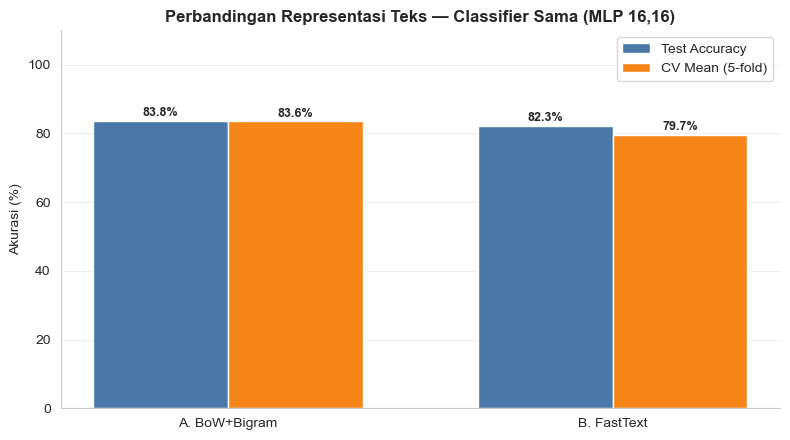

In [26]:
# 4.2 Grafik pembanding akurasi test & CV antar representasi
fig, ax = plt.subplots(figsize=(8, 4.5))
nama_skema = list(hasil.keys())
x_pos = np.arange(len(nama_skema))
lebar = 0.35

b1 = ax.bar(x_pos - lebar/2, [hasil[n]["test"]*100 for n in nama_skema], lebar, label="Test Accuracy", color="#4C78A8")
b2 = ax.bar(x_pos + lebar/2, [hasil[n]["cv_mean"]*100 for n in nama_skema], lebar, label=f"CV Mean ({n_splits}-fold)", color="#F58518")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", xy=(bar.get_x()+bar.get_width()/2, h), xytext=(0,3),
                    textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x_pos); ax.set_xticklabels(nama_skema)
ax.set_ylim(0, 110); ax.set_ylabel("Akurasi (%)")
ax.set_title("Perbandingan Representasi Teks — Classifier Sama (MLP 16,16)", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

In [27]:
# 4.3 Classification report detail untuk skema PRODUKSI (FastText)
mlp_ft_eval = model_test_per_skema["B. FastText"]
X_te_ft, y_te_ft = split_per_skema["B. FastText"]
print(classification_report(y_te_ft, mlp_ft_eval.predict(X_te_ft), zero_division=0))

                                   precision    recall  f1-score   support

               batal_ubah_pesanan       0.75      1.00      0.86         3
                harga_air_mineral       0.60      1.00      0.75         3
                  harga_americano       1.00      0.50      0.67         4
             harga_asparagus_puff       0.67      0.67      0.67         3
                    harga_au_lait       0.50      0.67      0.57         3
         harga_au_lait_cappuccino       0.67      0.50      0.57         4
              harga_avocado_shake       0.60      0.75      0.67         4
         harga_banana_cream_treat       1.00      1.00      1.00         4
            harga_beef_wellington       0.75      1.00      0.86         3
               harga_black_coffee       1.00      1.00      1.00         3
               harga_black_forest       1.00      1.00      1.00         3
           harga_black_tie_mousse       1.00      1.00      1.00         3
        harga_blaeter_te

### Uji Ketahanan OOV/Typo: keunggulan inti transfer learning FastText

Kalimat uji di bawah berisi kata yang **tidak pernah ada di data latih** (typo ekstrem, istilah baru). BoW menganggapnya vektor kosong/asing; FastText masih bisa "menebak" dari pecahan katanya.

In [28]:
# 4.4 Bandingkan prediksi BoW vs FastText pada input typo/OOV
uji_oov = [
    "hagra expersso brp ya",          # typo ganda: harga + espresso
    "kapucino satu brp duit",          # typo fonetik
    "ada wafel coklat ndak",           # typo + bahasa daerah
    "aku mau milkshake avocado dong",  # kasus yang dulu gagal
]

mlp_bow_eval = model_test_per_skema["A. BoW+Bigram"]
for kalimat in uji_oov:
    bersih = clean_text(kalimat)
    pred_bow = mlp_bow_eval.predict(vectorizer_bow.transform([bersih]))[0]
    prob_bow = mlp_bow_eval.predict_proba(vectorizer_bow.transform([bersih])).max()
    pred_ft  = mlp_ft_eval.predict(kalimat_ke_vektor(bersih).reshape(1, -1))[0]
    prob_ft  = mlp_ft_eval.predict_proba(kalimat_ke_vektor(bersih).reshape(1, -1)).max()
    print(f"'{kalimat}'")
    print(f"   BoW      -> {pred_bow:30s} ({prob_bow*100:.1f}%)")
    print(f"   FastText -> {pred_ft:30s} ({prob_ft*100:.1f}%)\n")

'hagra expersso brp ya'
   BoW      -> harga_frappe                   (13.5%)
   FastText -> harga_cappuccino               (78.9%)

'kapucino satu brp duit'
   BoW      -> sapaan                         (12.9%)
   FastText -> harga_cappuccino               (62.5%)

'ada wafel coklat ndak'
   BoW      -> tanya_menu                     (74.1%)
   FastText -> tanya_jenis_beans              (33.2%)

'aku mau milkshake avocado dong'
   BoW      -> mau_pesan                      (100.0%)
   FastText -> mau_pesan                      (100.0%)



## Bagian 5: Model Final Produksi & Ekspor

Model final dilatih ulang dari 100% data. Objek FastText tidak ikut di-pickle — yang disimpan cuma path-nya, FastAPI load keduanya terpisah saat startup.

In [29]:
# 5.1 Latih model final (100% data, representasi FastText) & simpan
final_model = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", max_iter=500, random_state=42)
final_model.fit(X_ft, y)

with open("chatbot_brain.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "intents": intents,
        "embedding": "fasttext",
        "fasttext_path": "fasttext-id-mini",   # FastAPI load file ini terpisah via CompressedFastTextKeyedVectors.load()
        "vector_dim": FT_DIM,
    }, f)

print("chatbot_brain.pkl tersimpan (MLP final + intents + referensi embedding).")

c:\Users\ASUS\miniconda3\envs\mlenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


chatbot_brain.pkl tersimpan (MLP final + intents + referensi embedding).


## Bagian 6: Logika Runtime: Marker Rekomendasi Dinamis

3 marker (`REKOMENDASI_KOPI`/`NON_KOPI`/`MAKANAN`) dipetakan ke fungsi Pandas per-kategori, dipanggil saat model memprediksi tag marker.

In [30]:
# 6.1 Fungsi rekomendasi per-kategori (dipanggil saat model memprediksi tag marker)
def _top3_kategori(daftar_kategori) -> list:
    sub = df_food[df_food["kategori"].isin(daftar_kategori)]
    terbaik = sub[sub["food_rating"] == sub["food_rating"].max()] \
        .sort_values("times_appeared", ascending=False)
    if terbaik.empty:                      # fallback bila tak ada rating maksimal di kategori itu
        terbaik = sub.sort_values("times_appeared", ascending=False)
    ids = terbaik["item_id"].head(3).tolist()
    urut = {v: k for k, v in enumerate(ids)}
    nama = df_items[df_items["id"].isin(ids)].copy()
    nama["urut"] = nama["id"].map(urut)
    return nama.sort_values("urut")["name"].str.strip().tolist()

def rekomendasi_kopi() -> str:
    menu = _top3_kategori([4])
    return ("Kalau untuk kopi, jagoan terlaris kami: " + ", ".join(menu) +
            ". Diseduh dari house blend Arabika Gayo & Robusta Temanggung. Mau coba salah satunya, kak? ☕")

def rekomendasi_non_kopi() -> str:
    menu = _top3_kategori([1])
    return ("Untuk yang bebas kafein, paling favorit: " + ", ".join(menu) +
            ". Seger dan aman di lambung! Mau dipesankan, kak? 🥤")

def rekomendasi_makanan() -> str:
    menu = _top3_kategori([2, 3])
    return ("Cemilan pendamping ngopi terlaris kami: " + ", ".join(menu) +
            ". Dijamin nagih, kak! Mau langsung dipesan? 🥐")

MARKER_HANDLER = {
    "REKOMENDASI_KOPI": rekomendasi_kopi,
    "REKOMENDASI_NON_KOPI": rekomendasi_non_kopi,
    "REKOMENDASI_MAKANAN": rekomendasi_makanan,
}

# Uji cepat ketiganya
for nama_marker, fungsi in MARKER_HANDLER.items():
    print(f"{nama_marker}:\n  {fungsi()}\n")

REKOMENDASI_KOPI:
  Kalau untuk kopi, jagoan terlaris kami: Iced Coffee Late, Simple Coffee, Latte Macchiato. Diseduh dari house blend Arabika Gayo & Robusta Temanggung. Mau coba salah satunya, kak? ☕

REKOMENDASI_NON_KOPI:
  Untuk yang bebas kafein, paling favorit: Peanut Vanila, Cotton candy shake, Tiramisu Milkshake. Seger dan aman di lambung! Mau dipesankan, kak? 🥤

REKOMENDASI_MAKANAN:
  Cemilan pendamping ngopi terlaris kami: Asparagus Puff, Red Velvet, Nutella Puff. Dijamin nagih, kak! Mau langsung dipesan? 🥐



In [31]:
# 6.2 predict_chat versi produksi: FastText + threshold + penanganan marker
def predict_chat(user_message: str, threshold: float = 0.35) -> str:
    bersih = clean_text(user_message)
    vektor = kalimat_ke_vektor(bersih).reshape(1, -1)

    prob = final_model.predict_proba(vektor)[0]
    max_prob = prob.max()
    tag = final_model.classes_[prob.argmax()]
    print(f"(debug) intent: '{tag}' | keyakinan: {max_prob*100:.1f}%")

    if max_prob < threshold:
        return "Maaf kak, aku belum paham maksudnya. Bisa infokan kembali menu atau harga apa yang ingin kamu tanyakan? 😊"

    for intent in intents:
        if intent["tag"] == tag:
            respons = random.choice(intent["responses"])
            if respons in MARKER_HANDLER:            # marker -> jawaban dinamis Pandas
                return MARKER_HANDLER[respons]()
            return respons
    return "Maaf, terjadi kesalahan sistem."

# CATATAN threshold: distribusi keyakinan model berbasis vektor dense biasanya lebih 'lembut'
# daripada BoW. 0.35 adalah titik awal -- amati nilai debug saat pengujian dan sesuaikan.

In [32]:
# 6.3 Simulasi menyeluruh: kasus normal + kasus yang dulu gagal + typo + out-of-scope
kalimat_uji = [
    "halo min",
    "rekomendasiin minuman kopi dong",        # -> marker REKOMENDASI_KOPI (dinamis!)
    "ada milkshake yang direkomendasiin ga",  # -> marker REKOMENDASI_NON_KOPI
    "cemilan yang enak apa kak",              # -> marker REKOMENDASI_MAKANAN
    "harga cappuccino berapa ya",
    "hagra expersso brp",                     # typo ganda -- uji subword FastText
    "apakah ada manual brew disini",          # dulu nyasar ke sapaan
    "apakah kamu tau v60",                    # dulu out-of-scope, kini tanya_metode_seduh
    "aku mau milkshake avocado dong",         # dulu fallback, kini mau_pesan
    "oke boleh, gas order itu aja",
    "asdkjaskjd random gatau apa",            # harus jatuh ke fallback threshold
]

for kalimat in kalimat_uji:
    print(f"User \t: {kalimat}")
    print(f"Bot \t: {predict_chat(kalimat)}")
    print("-" * 60)

User 	: halo min
(debug) intent: 'sapaan' | keyakinan: 100.0%
Bot 	: Halo, selamat datang di kafe kami! Ada yang bisa saya bantu? ☕
------------------------------------------------------------
User 	: rekomendasiin minuman kopi dong
(debug) intent: 'minta_rekomen_kopi' | keyakinan: 98.0%
Bot 	: Kalau untuk kopi, jagoan terlaris kami: Iced Coffee Late, Simple Coffee, Latte Macchiato. Diseduh dari house blend Arabika Gayo & Robusta Temanggung. Mau coba salah satunya, kak? ☕
------------------------------------------------------------
User 	: ada milkshake yang direkomendasiin ga
(debug) intent: 'minta_rekomen_non_kopi' | keyakinan: 96.0%
Bot 	: Untuk yang bebas kafein, paling favorit: Peanut Vanila, Cotton candy shake, Tiramisu Milkshake. Seger dan aman di lambung! Mau dipesankan, kak? 🥤
------------------------------------------------------------
User 	: cemilan yang enak apa kak
(debug) intent: 'minta_rekomen_makanan' | keyakinan: 100.0%
Bot 	: Cemilan pendamping ngopi terlaris kami: A